In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandana as pdna
import geopandas as gpd
import pandas as pd
import osmnx as ox
import math
import networkx as nx
import sys
import matplotlib.pyplot as plt
# adding functions 
sys.path.insert(0, 'C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Open-Walk-Index')
from walkability_functions import *

C:\Users\z3258367\AppData\Local\Temp\ipykernel_63864\2726539810.py:3: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


Choose a projected CRS to be used for all distance calculations.

In [3]:
folder = "C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Colouring data & results\\"
proj_crs = "EPSG:7856"

Get a polygon of the place from OpenStreetMap. Alternatively, upload a place_gdf of your choice.

In [4]:
place = 'Sydney, Australia'
place_gdf = ox.geocode_to_gdf(place).to_crs(proj_crs)

<AxesSubplot: >

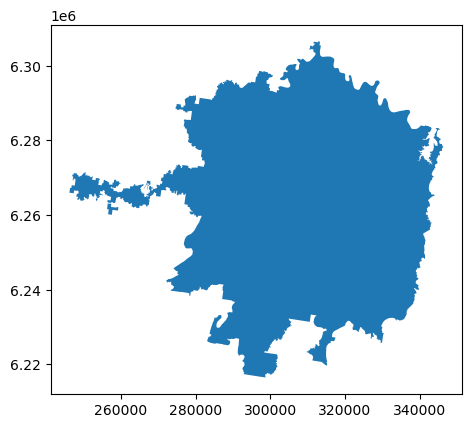

In [5]:
# check that we have the right place
place_gdf.geometry.plot()

## Import Data

Data sources:
1. OSM POIs
5. Employment data - in Australia this is based on open data from the Census, processed using the Employment Points notebook also available.

In [6]:
poi_dictionary = {
    'employment':{
        'category':['employment']
    },
    'shopping':{
        'shop':['bakery', 'clothes', 'supermarket', 'mall', 'greengrocer',
                'seafood', 'wine', 'butcher','convenience',
                'beverages', 'alcohol', 'bicycle_shop', 'department_store', 
                'doityourself', 'beauty_shop', 'outdoor_shop', 
                'stationery', 'bookshop', 'gift_shop', 'newsagent', 
                'car_dealership', 'furniture_shop', 'sports_shop',
                'garden_centre', 'computer_shop', 'shoe_shop', 'florist', 
                'video_shop', 'toy_shop', 'mobile_phone_shop', 'jeweller'],
        # possibly we could pick up all shop=True excluding a few. but not sure how
        # and many options to exclude
        'amenity':['marketplace'],
        'building':['kiosk', 'supermarket',],
    },
    'errands':{
        'amenity':['atm','bank','courthouse','post_box', 'post_office',
                   'clinic', 'dentist', 'doctors', 'hospital',
                   'pharmacy', 'veterinary', 'travel_agent',
                   'place_of_worship'],
        'shop':['optician', 'hairdresser', 'laundry',],
        'healthcare':['physiotherapist'],
        'office':['government'], #### further refine ?
    },
    'recreation':{
        'leisure':['dog_park', 'ice_rink', 'park', 'pitch', 'playground',
                   "fitness_centre","sports_centre", 'stadium', 'swimming_pool',
                   'swimming_area', 'track', 'water_park','golf_course',],
        'club':['social'],
        'amenity':['bar', 'biergarten', 'cafe', 'fast_food', 'food_court',
                   'ice_cream', 'pub', 'restaurant', 'nightclub',
                   'library', 'arts_centre', 'cinema', 'community_centre',
                   'social_centre', 'theatre',],
        'building':['stadium', 'castle', 'ruins',],
        'tourism':['aquarium', 'artwork', 'attraction', 'gallery',
                   'museum', 'picnic_site', 'theme_park', 'viewpoint',
                   'zoo'],
        'natural':['beach'],
    },
    'education':{
        'amenity':['college', 'kindergarten', 'music_school',
                   'school', 'university', 'childcare'],
    }
}

In [7]:
%%capture --no-stdout  
#hides deprecation warning related to Shapely and osmnx. turn off if something is not working.
osm_pois = poi_downloader(place_gdf, poi_dictionary, proj_crs)

In [8]:
employment_centrs = gpd.read_file((folder + 
                        "Sydney Data\\Data\\Centroids employment MBs.gpkg")).to_crs(proj_crs)

employment_centrs['category'] = 'employment'
employment_centrs['geometry'] = employment_centrs.geometry.centroid

In [9]:
employ_short = remove_duplicate_pois([employment_centrs], buffer=150, variable = 'Jobs_count')

Removed 26.17% duplicate points from dataframes - 1738 points


c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\geopandas\geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [10]:
employment_centrs['Jobs_count'].sum(), employ_short['Jobs_count'].sum(), employ_short['Jobs_count'].sum()/employment_centrs['Jobs_count'].sum()
#weird but cannot deal right now

(1161582.37, 1137066.791, 0.9788946702075031)

In [11]:
employ_short.to_file(folder + "Sydney Data\\Data\\merged 150 Centroids employment MBs.gpkg", driver="GPKG")

Need to remove potential overlap between different data sources (and inside some data sources). For now I'm not worrying about this when using only OSM data. Then take this combined POI set and clip it to the study area: should be the same area as is covered by the network. This is important otherwise points outside the network may be erroneously linked to the network.

In [12]:
pois = pd.concat([osm_pois, employ_short])

pois = gpd.clip(pois, place_gdf.to_crs(proj_crs))

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\geopandas\array.py:1406: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as GDA2020 / MGA zone 56 (the single non-null crs provided).
  warnings.warn(


### Categorise and weight POIs

Choose walk index weightings, and output the sums of each category and the total to check. The walk index will be out of 100 regardless of this sum, but it is important to note that eg. shopping is only '10% of the walk index' if shopping is 10 out of 100.

In [13]:
poi_parameters = pd.read_csv((folder + 
                              "Shared Aus Data\\poi_parameters_5.csv"),
                            index_col=0)

In [14]:
poi_weights = poi_parameters['weight'].copy()

poi_lambdas = poi_parameters['diminishing_returns_constant'].copy()

poi_variables = poi_parameters['variable'].copy()

poi_nums = poi_parameters['num_pois'].copy()

poi_gammas = poi_parameters['distance_constant'].copy()

In [15]:
print("total: ", sum(poi_weights))

total:  100.00000000000001


In [16]:
# change this to match the column containing job counts in your employment dataframe
poi_variables.loc['employment'] = 'Jobs_count'
# change this to make employment score more accurate (higher number) or to reduce index calculation time (low number)
poi_nums.loc['employment'] = 1200

# 1. Walking

## Pandana network creation.

Pandana expects edges to have a two item index based on the same IDs as the node index. (with thanks to https://github.com/shriv/accessibility-series/blob/master/Accounting%20for%20hills%20in%20accessibility%20analyses.ipynb)

In [14]:
#G = ox.graph_from_place(place, network_type='walk')
G = ox.graph.graph_from_polygon(place_gdf.to_crs('EPSG:4326').geometry[0], network_type='walk')

In [15]:
# Get nodes and edges as geodataframes (gdfs) from OSMNX network
graph_df = ox.graph_to_gdfs(G)
nodes_gdfs = graph_df[0].to_crs(proj_crs)
edges_gdfs = graph_df[1].to_crs(proj_crs)

In [16]:
# with new OSMnx graph from polygon seems to be different
edges_gdfs = edges_gdfs.reset_index()
# Setting indices of Edges gdfs to match expected dataframe for Pandana
edges_gdfs['from_idx'] = edges_gdfs['u']
edges_gdfs['to_idx'] = edges_gdfs['v']
edges_gdfs= edges_gdfs.set_index(['from_idx', 'to_idx'])
edges_gdfs.index.names= ['','']

# Setting indices of Nodes gdfs to match expected dataframe for Pandana
nodes_gdfs.index.name = 'id'

In [17]:
# Create a pandana network with data extracted from an OSMNX graph
distance_network = pdna.Network(nodes_gdfs.geometry.x, nodes_gdfs.geometry.y,
                                   edges_gdfs['u'], edges_gdfs['v'], 
                                   edges_gdfs[['length']])

### Pandana network querying. 

In [18]:
maximum_dist=2400

In [19]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_walk = there_index(distance_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=maximum_dist)

Finished category: employment
Maximum score: 16.67334316193792 out of 31.9
Finished category: education
Maximum score: 9.006685312201533 out of 14.3
Finished category: shopping
Maximum score: 15.992823291179144 out of 21.6
Finished category: errands
Maximum score: 6.563501978934795 out of 8.9
Finished category: recreation
Maximum score: 17.2515177168738 out of 23.3


In [20]:
# sanity check
max(results_walk['THERE_Index']), np.mean(results_walk['THERE_Index'])

(59.86675599462695, 24.05163065174009)

# 2. Driving

## Pandana network creation.

Pandana expects edges to have a two item index based on the same IDs as the node index. (with thanks to https://github.com/shriv/accessibility-series/blob/master/Accounting%20for%20hills%20in%20accessibility%20analyses.ipynb)

In [14]:
#G = ox.graph_from_place(place, network_type='walk')
G = ox.graph.graph_from_polygon(place_gdf.to_crs('EPSG:4326').geometry[0], network_type='drive')

In [15]:
# Get nodes and edges as geodataframes (gdfs) from OSMNX network
graph_df = ox.graph_to_gdfs(G)
nodes_gdfs = graph_df[0].to_crs(proj_crs)
edges_gdfs = graph_df[1].to_crs(proj_crs)

In [16]:
# with new OSMnx graph from polygon seems to be different
edges_gdfs = edges_gdfs.reset_index()
# Setting indices of Edges gdfs to match expected dataframe for Pandana
edges_gdfs['from_idx'] = edges_gdfs['u']
edges_gdfs['to_idx'] = edges_gdfs['v']
edges_gdfs= edges_gdfs.set_index(['from_idx', 'to_idx'])
edges_gdfs.index.names= ['','']

# Setting indices of Nodes gdfs to match expected dataframe for Pandana
nodes_gdfs.index.name = 'id'

In [17]:
# Create a pandana network with data extracted from an OSMNX graph
drive_network = pdna.Network(nodes_gdfs.geometry.x, nodes_gdfs.geometry.y,
                                   edges_gdfs['u'], edges_gdfs['v'], 
                                   edges_gdfs[['length']])

In [ ]:
drive_gammas = poi_gammas.copy()
drive_gammas = drive_gammas.replace(to_replace=0.001, value=0.00005)

### Pandana network querying. 

In [20]:
drive_dist=24000

In [21]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_drive = there_index(drive_network, pois, poi_dictionary, poi_weights, drive_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=drive_dist)

Finished category: employment
Maximum score: 29.96065204546791 out of 31.9
Finished category: education
Maximum score: 14.18213900417212 out of 14.3
Finished category: shopping
Maximum score: 21.58805337760481 out of 21.6
Finished category: errands
Maximum score: 8.894112493170292 out of 8.9
Finished category: recreation
Maximum score: 23.287113134175556 out of 23.3


In [22]:
# sanity check
max(results_drive['THERE_Index']), np.mean(results_drive['THERE_Index'])

(97.49630224470276, 83.0279444433144)

# 3. Cycling

In [36]:
# To create a 'cycling friendly' network it is useful to have some additional tags
ox.settings.useful_tags_way = list(set(ox.settings.useful_tags_way + 
                                       ['bicycle'] + ['foot'] + ['cycleway'] + ['cycleway:left'] + ['cycleway:right']))

### change parameters

In [15]:
cycle_gammas = poi_gammas.copy()
cycle_gammas = cycle_gammas.replace(to_replace=0.001, value=0.0002)
cycle_dist = 12000

## Initial Pandana network creation.

In [37]:
G = ox.graph.graph_from_polygon(place_gdf.to_crs('EPSG:4326').geometry[0], network_type='bike')

Pandana expects edges to have a two item index based on the same IDs as the node index. (with thanks to https://github.com/shriv/accessibility-series/blob/master/Accounting%20for%20hills%20in%20accessibility%20analyses.ipynb)

In [38]:
# Get nodes and edges as geodataframes (gdfs) from OSMNX network
graph_df = ox.graph_to_gdfs(G)
nodes_gdfs = graph_df[0].to_crs(proj_crs)
edges_gdfs = graph_df[1].to_crs(proj_crs)

For walking it's ok to assume all edges are two-way, but for cycling and driving it's not. So we need to create Pandana networks with twoway=False, but first, duplicate & flip the OSM edges that are two-way.

In [45]:
edges_gdfs = edges_gdfs.reset_index()

# 2017 David Wasserman via Pandana github forum
twoway_edges = edges_gdfs[edges_gdfs['oneway'] == False].copy()
twoway_to = twoway_edges["u"].copy()
twoway_edges["u"] = twoway_edges["v"]
twoway_edges["v"] = twoway_to
edges_gdfs = pd.concat([edges_gdfs, twoway_edges])

In [51]:
edges_gdfs['cycleway'] = edges_gdfs['cycleway'].fillna(edges_gdfs['cycleway:left'])
edges_gdfs['cycleway'] = edges_gdfs['cycleway'].fillna(edges_gdfs['cycleway:right'])

In [55]:
# Setting indices of Edges gdfs to match expected dataframe for Pandana
edges_gdfs['from_idx'] = edges_gdfs['u']
edges_gdfs['to_idx'] = edges_gdfs['v']
edges_gdfs= edges_gdfs.set_index(['from_idx', 'to_idx'])
edges_gdfs.index.names= ['','']

# Setting indices of Nodes gdfs to match expected dataframe for Pandana
nodes_gdfs.index.name = 'id'
# Create a pandana network with data extracted from an OSMNX graph
cycle_network = pdna.Network(nodes_gdfs.geometry.x, nodes_gdfs.geometry.y, 
                             edges_gdfs['u'], edges_gdfs['v'], 
                             edges_gdfs[['length']], 
                             twoway=False)

### Pandana network querying. 

In [49]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_cycle = there_index(cycle_network, pois, poi_dictionary, poi_weights, cycle_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=cycle_dist)

Finished category: employment
Maximum score: 26.42527441052821 out of 31.9
Finished category: education
Maximum score: 13.809898517379082 out of 14.3
Finished category: shopping
Maximum score: 21.58805337760481 out of 21.6
Finished category: errands
Maximum score: 8.889488900482274 out of 8.9
Finished category: recreation
Maximum score: 23.287113134175556 out of 23.3


In [50]:
# sanity check
max(results_cycle['THERE_Index']), np.mean(results_cycle['THERE_Index'])

(92.00580878571954, 61.04775869911857)

## More conservative cycle network
Here we remove all primary, secondary, trunk, busway and associated links with speed >= 50km/hr (which in practice means unknown or > 40km/hr). (Busway in Sydney is used for separated busways ie. the T-way, not regular bus lanes). Also remove 'unclassified' links unless: they are tagged foot = yes, cycleway = designated, or maxspeed < 50km/hr.

In [60]:
# some values of OSM tag maxspeed are unwieldy, eg text containing kmh, lists (produced by OSMNx simplification) etc. 
# This tries to strip text, but for lists, NaN etc gives up and returns the default speed in NSW - 50km/hr.
# Note that OSMNx simplification already collapses lists when values are the same.
# The most common case of lists is speed limit changes on arterial roads, eg the list is [60,80],  
# which is all equivalent to >50 for the purposes of this bicycle network anyway.

def int_50(n):
    try:
        return int(n)
    except:
        try:
            return int(filter(lambda x: x in '0123456789.', n))
        except:
            return 50
    
edges_gdfs['inferred_speed'] = edges_gdfs['maxspeed'].apply(int_50)

In [304]:
main_roads = ['primary', 'primary_link', 'secondary', 'secondary_link', 'trunk', 'trunk_link', 
              'tertiary', 'tertiary_link', 'busway']

cycle_edges = edges_gdfs[~((edges_gdfs['highway'].apply(lambda l: any([x in l for x in main_roads]))) 
                           & (edges_gdfs['inferred_speed']>=50))]
cycle_edges = cycle_edges[~((cycle_edges['highway'] == 'unclassified') & 
                            ~((cycle_edges['inferred_speed'] < 50)|
                              (cycle_edges['foot'] == 'yes')|
                              (cycle_edges['bicycle'] == 'designated')))]

In [309]:
main_roads = ['primary', 'primary_link', 'secondary', 'secondary_link', 'trunk', 'trunk_link', 
              'tertiary', 'tertiary_link', 'busway']

cycle_edges = edges_gdfs[~(
    (
        (edges_gdfs['highway'].apply(lambda l: any([x in l for x in main_roads]))) 
        & 
        (edges_gdfs['inferred_speed']>=50)
    ) 
    | 
    (
        (edges_gdfs['highway'] == 'unclassified') 
        & 
        ~((edges_gdfs['inferred_speed'] < 50)|(edges_gdfs['foot'] == 'yes')|(edges_gdfs['bicycle'] == 'designated'))
    )
    )]

In [310]:
len(cycle_edges)/len(edges_gdfs), sum(cycle_edges.length)/sum(edges_gdfs.length)

(0.7885981521143082, 0.7839137812403802)

22% of links removed.

In [327]:
edge_export = cycle_edges.reset_index(drop=True)

In [354]:
analysis_edges = edges_gdfs.copy()

In [355]:
for col in analysis_edges.columns:
    if any(isinstance(val, list) for val in analysis_edges[col]):
        analysis_edges[col] = analysis_edges[col].astype(str)

In [332]:
edge_export.to_file("C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\HPM take 2\\selective_cycle_net.gpkg")

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\io\file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\io\file.py:389: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(gdal_version) >= LooseVersion("3.0.0") and crs:


In [356]:
analysis_edges.columns

Index(['u', 'v', 'key', 'osmid', 'ref', 'highway', 'oneway', 'maxspeed',
       'name', 'lanes', 'reversed', 'length', 'geometry', 'cycleway', 'bridge',
       'bicycle', 'foot', 'width', 'access', 'junction', 'service', 'tunnel',
       'est_width', 'area', 'landuse', 'speed', 'inferred_speed'],
      dtype='object')

## New 'selective' cycling network creation

In [317]:
# Create a pandana network with edges filter as above
cycle_network = pdna.Network(nodes_gdfs.geometry.x, nodes_gdfs.geometry.y, 
                             edges_gdfs['u'], edges_gdfs['v'], 
                             edges_gdfs[['length']], 
                             two_way=False)

### Pandana network querying. 

In [318]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_cycle_selective = there_index(cycle_network_selective, pois, poi_dictionary, poi_weights, cycle_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=cycle_dist)

Finished category: employment
Maximum score: 25.265991365177427 out of 31.9
Finished category: education
Maximum score: 13.590000542753726 out of 14.3
Finished category: shopping
Maximum score: 21.58805337760481 out of 21.6
Finished category: errands
Maximum score: 8.881917357002742 out of 8.9
Finished category: recreation
Maximum score: 23.287113134175556 out of 23.3


In [319]:
# sanity check
max(results_cycle_selective['THERE_Index']), np.mean(results_cycle_selective['THERE_Index'])

(90.87808142734328, 27.40562131671422)

# Cycling impedance network

In [82]:
typeconds = [edges_gdfs['bicycle'] == 'no',
            edges_gdfs['cycleway'] == 'track',
            edges_gdfs['cycleway'] == 'lane',
            edges_gdfs['cycleway'].isin(['shared_path', 'crossing']),
            edges_gdfs['cycleway'] == 'shared_busway',
            (edges_gdfs['cycleway'].isin(['shared_lane', 'doorzone'])) | (edges_gdfs['bicycle']=='yes')]
typechoices = ['prohibited',
             'track',
             'lane',
             'shared_path',
             'shared_busway',
             'sharrow']

edges_gdfs['cycleway_type'] = np.select(typeconds, typechoices, default = 'no_cycleway')

In [86]:
condlist = [edges_gdfs['cycleway_type'] == 'prohibited',
            edges_gdfs['cycleway_type'] == 'track',
            edges_gdfs['cycleway_type'] == 'shared_path',
            edges_gdfs['cycleway_type'] == 'shared_busway',
            edges_gdfs['inferred_speed'] <= 30,
            (edges_gdfs['highway'].isin(['residential','unclassified'])) & (edges_gdfs['cycleway_type'] == 'lane'),
            (edges_gdfs['highway'].isin(['residential','unclassified'])) & (edges_gdfs['cycleway_type'] == 'sharrow'),
            (edges_gdfs['highway'].isin(['residential','unclassified'])) & (edges_gdfs['cycleway_type'] == 'no_cycleway'),
            (edges_gdfs['highway'] == 'tertiary') & (edges_gdfs['cycleway'] == 'lane'),
            (edges_gdfs['highway'] == 'tertiary') & (edges_gdfs['cycleway'] == 'sharrow'),
            (edges_gdfs['highway'] == 'tertiary') & (edges_gdfs['cycleway'] == 'no_cycleway'),
            (edges_gdfs['highway'] == 'secondary') & (edges_gdfs['cycleway'] == 'lane'),
            (edges_gdfs['highway'] == 'secondary') & (edges_gdfs['cycleway'] == 'sharrow'),
            (edges_gdfs['highway'] == 'secondary') & (edges_gdfs['cycleway'] == 'no_cycleway'),
            (edges_gdfs['highway'] == 'primary') & (edges_gdfs['cycleway'] == 'lane'),
            (edges_gdfs['highway'] == 'primary') & (edges_gdfs['cycleway'] == 'sharrow'),
            (edges_gdfs['highway'] == 'primary') & (edges_gdfs['cycleway'] == 'no_cycleway'),]
choicelist = [5, 1, 1.5, 1.5, 1.1, 
             1.1, 1.2, 1.3, # residential and unclassified
             2, 2.5, 3, # tertiary
             3, 3.5, 4, # secondary
             4, 4.5, 5] # primary
edges_gdfs['cycle_impedance'] = np.select(condlist, choicelist, default = 5)

In [99]:
edges_gdfs['cycle_cost'] = edges_gdfs['cycle_impedance']*edges_gdfs['length']

In [101]:
# Create a pandana network with edges filter as above
# ideally we can create it with multiple impedances, but I would need to rewrite the index function to select one
cycle_network_imp = pdna.Network(nodes_gdfs.geometry.x, nodes_gdfs.geometry.y, 
                             edges_gdfs['u'], edges_gdfs['v'], 
                             edge_weights=edges_gdfs[['cycle_cost']],                           
                             twoway=False)

### Pandana network querying. 

In [102]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_cycle_impedance = there_index(cycle_network_imp, pois, poi_dictionary, poi_weights, cycle_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=cycle_dist)

Finished category: employment
Maximum score: 21.619766563099695 out of 31.9
Finished category: education
Maximum score: 13.40530785200018 out of 14.3
Finished category: shopping
Maximum score: 21.58805337760481 out of 21.6
Finished category: errands
Maximum score: 8.887790030168157 out of 8.9
Finished category: recreation
Maximum score: 23.287113134175556 out of 23.3


In [103]:
# sanity check
max(results_cycle_impedance['THERE_Index']), np.mean(results_cycle_impedance['THERE_Index'])

(85.16179770959512, 40.97020199865498)

# 4. Public Transport - pre-saved network further down

In [18]:
import urbanaccess as ua
from urbanaccess.config import settings
from urbanaccess.gtfsfeeds import feeds
from urbanaccess import gtfsfeeds
from urbanaccess.gtfs.gtfsfeeds_dataframe import gtfsfeeds_dfs
from urbanaccess.network import ua_network, load_network

In [21]:
bbox = place_gdf.to_crs("EPSG:4326").bounds
bbox_points = (bbox['minx'][0], bbox['miny'][0], bbox['maxx'][0], bbox['maxy'][0])

loaded_feeds = ua.gtfs.load.gtfsfeed_to_df(gtfsfeed_path=('C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\' 
                                                          + "Data\\TfNSW\\full_greater_sydney_gtfs_static_15.12"), 
                                     validation=True, 
                                     verbose=True, 
                                     bbox=bbox_points, 
                                     remove_stops_outsidebbox=True, 
                                     append_definitions=True)

Checking GTFS text file header whitespace... Reading files using encoding: utf-8 set in configuration.


GTFS text file header whitespace check completed. Took 1.10 seconds
--------------------------------
Processing GTFS feed: full_greater_sydney_gtfs_static_15.12


c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\utils_format.py:1066: FutureWarning: The default value of regex will change from True to False in a future version.
  col_snake_case = col.str.replace(r'\s+', '_')


GTFS feed: full_greater_sydney_gtfs_static_15.12, calendar_dates uses the same service_id across multiple agency_ids. This feed calendar_dates table will be modified from its original format to provide service_ids for each agency using a one to many join


c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\utils_format.py:1066: FutureWarning: The default value of regex will change from True to False in a future version.
  col_snake_case = col.str.replace(r'\s+', '_')


...

GTFS feed: full_greater_sydney_gtfs_static_15.12, stops uses the same stop_id across multiple agency_ids. This feed stops table will be modified from its original format to provide stop_ids for each agency using a one to many join


c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\utils_format.py:1066: FutureWarning: The default value of regex will change from True to False in a future version.
  col_snake_case = col.str.replace(r'\s+', '_')
c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\utils_format.py:1066: FutureWarning: The default value of regex will change from True to False in a future version.
  col_snake_case = col.str.replace(r'\s+', '_')


agency.txt agency_name column has more than one agency name listed. Unique agency id was assigned using the agency id and associated agency name.
Unique agency id operation complete. Took 36.17 seconds
Unique GTFS feed id operation complete. Took 0.03 seconds
Records:
       stop_id                 unique_agency_id  stop_code  \
326     253330                              nan        NaN   
327     253331  train_replacement_bus_operators   253331.0   
328     253331          kennedy's_bus_and_coach   253331.0   
329     253331                premier_illawarra   253331.0   
330     253331                 kiama_coachlines   253331.0   
...        ...                              ...        ...   
122363  G37403                              nan        NaN   
122364  G37407                              nan        NaN   
122365  G37408                              nan        NaN   
122366  G39004                              nan        NaN   
122367  G47788                              nan  

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\load.py:393: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  merged_stops_df = merged_stops_df.append(stops_df, ignore_index=True)
c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\load.py:394: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  merged_routes_df = merged_routes_df.append(routes_df,
c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\load.py:396: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  merged_trips_df = merged_trips_df.append(trips_df, ignore_index=True)
c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\load.py:397: FutureWarning: The frame.append method is deprecated 

--------------------------------
Added descriptive definitions to stops, routes, stop_times, and trips tables
Successfully converted ['departure_time'] to seconds past midnight and appended new columns to stop_times. Took 11.97 seconds
1 GTFS feed file(s) successfully read as dataframes:
     full_greater_sydney_gtfs_static_15.12
     Took 61.60 seconds


<AxesSubplot: xlabel='stop_lon', ylabel='stop_lat'>

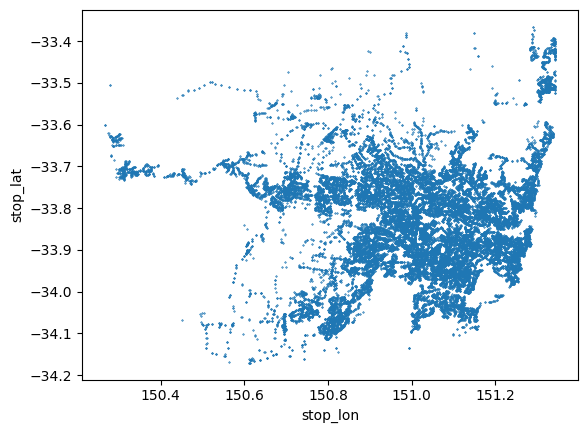

In [22]:
loaded_feeds.stops.plot(kind='scatter', x='stop_lon', y='stop_lat', s=0.1)

In [23]:
ua.gtfs.network.create_transit_net(gtfsfeeds_dfs=loaded_feeds,
                                   day='monday',
                                   timerange=['07:00:00', '12:00:00'],
                                   calendar_dates_lookup=None)

Using calendar to extract service_ids to select trips.
1,171 service_ids were extracted from calendar
88,308 trip(s) 46.57 percent of 189,640 total trip records were found in calendar for GTFS feed(s): ['full greater sydney gtfs static 15.12']
NOTE: If you expected more trips to have been extracted and your GTFS feed(s) have a calendar_dates file, consider utilizing the calendar_dates_lookup parameter in order to add additional trips based on information inside of calendar_dates. This should only be done if you know the corresponding GTFS feed is using calendar_dates instead of calendar to specify service_ids. When in doubt do not use the calendar_dates_lookup parameter.
88,308 of 189,640 total trips were extracted representing calendar day: monday. Took 0.32 seconds
There are no departure time records missing from trips following the specified schedule. There are no records to interpolate.
Difference between stop times has been successfully calculated. Took 0.44 seconds
Stop times fro

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\urbanaccess\gtfs\network.py:744: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for trip, tmp_trip_df in stop_times_df.groupby(['unique_trip_id']):


stop time table transformation to Pandana format edge table completed. Took 31.67 seconds
Time conversion completed: seconds converted to minutes.
27,215 of 55,240 records selected from stops. Took 0.14 seconds
stop time table transformation to Pandana format node table completed. Took 0.03 seconds
route type successfully joined to transit edges. Took 9.42 seconds
route id successfully joined to transit edges. Took 0.59 seconds
Successfully created transit network. Took 49.45 seconds


In [24]:
urbanaccess_net = ua.network.ua_network

In [25]:
ua.gtfs.headways.headways(gtfsfeeds_df=loaded_feeds,
                          headway_timerange=['07:00:00','12:00:00'])

Stop times from 07:00:00 to 12:00:00 successfully selected 717,599 records out of 2,261,672 total records (31.73 percent of total). Took 0.12 seconds
Starting route stop headway calculation for 58,730 route stops...
Route stop headway calculation complete. Took 119.64 seconds
headway calculation complete. Took 128.52 seconds


In [26]:
# lilli pilli stop id 2229181 (I think), 2229181_transdev_nsw is unique_stop_id
loaded_feeds.headways[loaded_feeds.headways['unique_stop_id']=='2229181_transdev_nsw']

,count,mean,std,min,25%,50%,75%,max,unique_stop_id,unique_route_id,node_id_route
78037,17.0,15.882353,6.122524,5.0,15.0,15.0,15.0,30.0,2229181_transdev_nsw,32-977-sj2-1_transdev_nsw,2229181_transdev_nsw_32-977-sj2-1_transdev_nsw
78939,17.0,15.882353,6.122524,5.0,15.0,15.0,15.0,30.0,2229181_transdev_nsw,32-977-sj2-1_transdev_nsw,2229181_transdev_nsw_32-977-sj2-1_transdev_nsw
79886,17.0,15.882353,6.122524,5.0,15.0,15.0,15.0,30.0,2229181_transdev_nsw,32-977-sj2-1_transdev_nsw,2229181_transdev_nsw_32-977-sj2-1_transdev_nsw
79971,17.0,15.882353,6.122524,5.0,15.0,15.0,15.0,30.0,2229181_transdev_nsw,32-977-sj2-1_transdev_nsw,2229181_transdev_nsw_32-977-sj2-1_transdev_nsw
80007,17.0,15.882353,6.122524,5.0,15.0,15.0,15.0,30.0,2229181_transdev_nsw,32-977-sj2-1_transdev_nsw,2229181_transdev_nsw_32-977-sj2-1_transdev_nsw
80043,17.0,15.882353,6.122524,5.0,15.0,15.0,15.0,30.0,2229181_transdev_nsw,32-977-sj2-1_transdev_nsw,2229181_transdev_nsw_32-977-sj2-1_transdev_nsw
80079,17.0,15.882353,6.122524,5.0,15.0,15.0,15.0,30.0,2229181_transdev_nsw,32-977-sj2-1_transdev_nsw,2229181_transdev_nsw_32-977-sj2-1_transdev_nsw
97326,17.0,15.882353,6.122524,5.0,15.0,15.0,15.0,30.0,2229181_transdev_nsw,32-977-sj2-1_transdev_nsw,2229181_transdev_nsw_32-977-sj2-1_transdev_nsw
97376,17.0,15.882353,6.122524,5.0,15.0,15.0,15.0,30.0,2229181_transdev_nsw,32-977-sj2-1_transdev_nsw,2229181_transdev_nsw_32-977-sj2-1_transdev_nsw
97426,17.0,15.882353,6.122524,5.0,15.0,15.0,15.0,30.0,2229181_transdev_nsw,32-977-sj2-1_transdev_nsw,2229181_transdev_nsw_32-977-sj2-1_transdev_nsw


In [34]:
# not using now
nodes, edges = ua.osm.load.ua_network_from_bbox(bbox=bbox_points, remove_lcn=True, network_type='walk')

Requesting network data within bounding box from Overpass API in 6 request(s)
Posting to http://www.overpass-api.de/api/interpreter with timeout=180, "{'data': '[out:json][timeout:180];(way["highway"]["highway"!~"motor|proposed|construction|abandoned|platform|raceway"]["foot"!~"no"]["pedestrians"!~"no"](-34.17427805,150.26082500,-33.75913708,150.61594110);>;);out;'}"


C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\osmnet\load.py:237: DeprecationWarning: Flags not at the start of the expression '//(?s)(.*?)/'
  domain = re.findall(r'//(?s)(.*?)/', url)[0]


Downloaded 3,069.1KB from www.overpass-api.de in 2.76 seconds
Posting to http://www.overpass-api.de/api/interpreter with timeout=180, "{'data': '[out:json][timeout:180];(way["highway"]["highway"!~"motor|proposed|construction|abandoned|platform|raceway"]["foot"!~"no"]["pedestrians"!~"no"](-33.76651019,150.26082500,-33.36418640,150.62694930);>;);out;'}"
Downloaded 18,232.0KB from www.overpass-api.de in 5.88 seconds
Posting to http://www.overpass-api.de/api/interpreter with timeout=180, "{'data': '[out:json][timeout:180];(way["highway"]["highway"!~"motor|proposed|construction|abandoned|platform|raceway"]["foot"!~"no"]["pedestrians"!~"no"](-33.77306901,150.61594110,-33.36522190,150.99314586);>;);out;'}"
Downloaded 41,126.2KB from www.overpass-api.de in 9.10 seconds
Posting to http://www.overpass-api.de/api/interpreter with timeout=180, "{'data': '[out:json][timeout:180];(way["highway"]["highway"!~"motor|proposed|construction|abandoned|platform|raceway"]["foot"!~"no"]["pedestrians"!~"no"](-

In [27]:
# alternative to use previous OSMNx created network (walk section) which does not discard culdesac end points
nodes, edges = nodes_gdfs, edges_gdfs

In [28]:
edges['distance'] = edges['length']

In [29]:
ua.osm.network.create_osm_net(osm_edges=edges,
                              osm_nodes=nodes,
                              travel_speed_mph=1.875)

Created OSM network with travel time impedance using a travel speed of 1.875 MPH. Took 0.02 seconds


<AxesSubplot: xlabel='x', ylabel='y'>

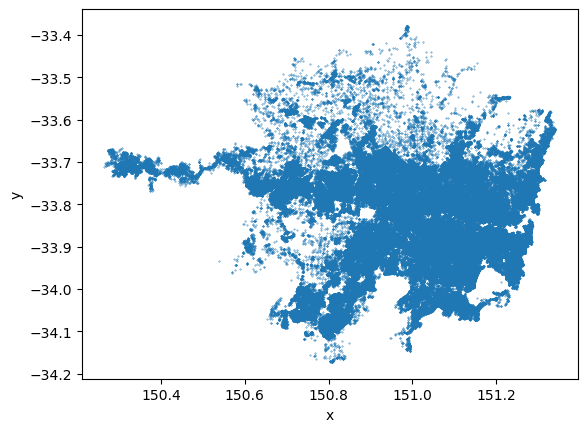

In [30]:
urbanaccess_net.osm_nodes.plot(kind='scatter', x='x', y='y', s=0.1)

In [31]:
urbanaccess_net.osm_edges['to'] = urbanaccess_net.osm_edges['v']
urbanaccess_net.osm_edges['from'] = urbanaccess_net.osm_edges['u']

In [32]:
# for some reason this prevents a memoryerror in the network integration step
urbanaccess_net.osm_nodes['id'] = urbanaccess_net.osm_nodes.index

In [33]:
ua.network.integrate_network(urbanaccess_network=urbanaccess_net,
                             headways=True,
                             urbanaccess_gtfsfeeds_df=loaded_feeds,
                             headway_statistic='mean')

Loaded UrbanAccess network components comprised of:
     Transit: 27,215 nodes and 691,917 edges;
     OSM: 286,288 nodes and 797,786 edges
routes successfully joined to transit nodes. Took 1.14 seconds
Connector edges between the OSM and transit network nodes successfully completed. Took 23.90 seconds
mean route stop headway will be used for pedestrian to transit edge impedance.
Headway impedance calculation completed. Took 0.42 seconds


c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\geopandas\array.py:1406: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as GDA2020 / MGA zone 56 (the single non-null crs provided).
  warnings.warn(
c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\geopandas\array.py:1406: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as GDA2020 / MGA zone 56 (the single non-null crs provided).
  warnings.warn(


Edge and node tables formatted for Pandana with integer node ids: id_int, to_int, and from_int. Took 18.40 seconds
Network edge and node network integration completed successfully resulting in a total of 345,001 nodes and 2,265,995 edges:
     Transit: 58,713 nodes 691,917 edges;
     OSM: 286,288 nodes 797,786 edges; and
     OSM/Transit connector: 776,292 edges.


In [34]:
original_edges = urbanaccess_net.net_edges.copy()

original_nodes = urbanaccess_net.net_nodes.copy()

urbanaccess_net.net_edges = urbanaccess_net.net_edges.drop('geometry', axis=1)

urbanaccess_net.net_nodes = urbanaccess_net.net_nodes.drop('geometry', axis=1)

In [114]:
# need to remove geometry column (or any LineStrings etc) for this to work
ua.network.save_network(urbanaccess_network=urbanaccess_net,
                        filename="Sydney_integrated_net_060123.h5",
                        dir = (folder + "Sydney Data"),
                        overwrite_key = True)

New Sydney_integrated_net_060123.h5 hdf5 store created in dir: C:\Users\z3258367\OneDrive - UNSW\#PhD\Walkability\Other Cities\Colouring data & results\Sydney Data


C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\tables\leaf.py:318: RuntimeWarning: overflow encountered in long_scalars
  expected_mb = (expectedrows * rowsize) // MB


edges saved in C:\Users\z3258367\OneDrive - UNSW\#PhD\Walkability\Other Cities\Colouring data & results\Sydney Data/Sydney_integrated_net_060123.h5 hdf5 store.
Using existing C:\Users\z3258367\OneDrive - UNSW\#PhD\Walkability\Other Cities\Colouring data & results\Sydney Data/Sydney_integrated_net_060123.h5 hdf5 store.
nodes saved in C:\Users\z3258367\OneDrive - UNSW\#PhD\Walkability\Other Cities\Colouring data & results\Sydney Data/Sydney_integrated_net_060123.h5 hdf5 store.


# Public Transport - pre saved network

In [ ]:
import urbanaccess as ua
from urbanaccess.config import settings
from urbanaccess.gtfsfeeds import feeds
from urbanaccess import gtfsfeeds
from urbanaccess.gtfs.gtfsfeeds_dataframe import gtfsfeeds_dfs
from urbanaccess.network import ua_network, load_network

In [19]:
urbanaccess_net = ua.network.load_network(filename='Sydney_integrated_net_060123.h5', dir = (folder + "Sydney Data"))

Successfully read store: C:\Users\z3258367\OneDrive - UNSW\#PhD\Walkability\Other Cities\Colouring data & results\Sydney Data/Sydney_integrated_net_060123.h5 with the following keys: ['/edges', '/nodes']
Successfully read store: C:\Users\z3258367\OneDrive - UNSW\#PhD\Walkability\Other Cities\Colouring data & results\Sydney Data/Sydney_integrated_net_060123.h5 with the following keys: ['/edges', '/nodes']


<AxesSubplot: xlabel='x', ylabel='y'>

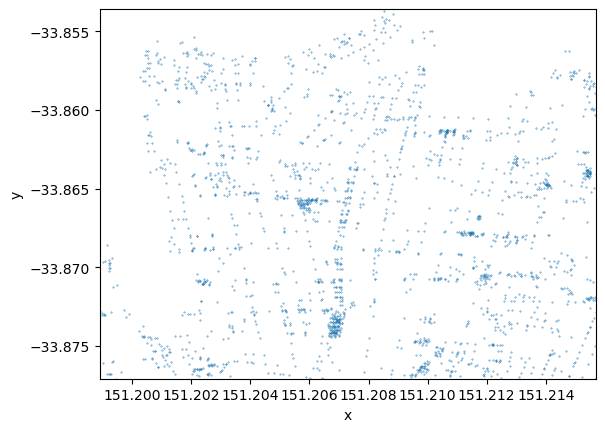

In [20]:
urbanaccess_net.net_nodes.loc[urbanaccess_net.net_nodes['net_type']=='walk'].plot(kind='scatter',
                               x='x', y='y', s=0.1, xlim=(151.198899,151.215686), ylim=(-33.877090,-33.853582))

In [21]:
transit_ped_net = pdna.Network(urbanaccess_net.net_nodes["x"],
                               urbanaccess_net.net_nodes["y"],
                               urbanaccess_net.net_edges["from_int"],
                               urbanaccess_net.net_edges["to_int"],
                               urbanaccess_net.net_edges[["weight"]], 
                               twoway=False)

<AxesSubplot: xlabel='x', ylabel='y'>

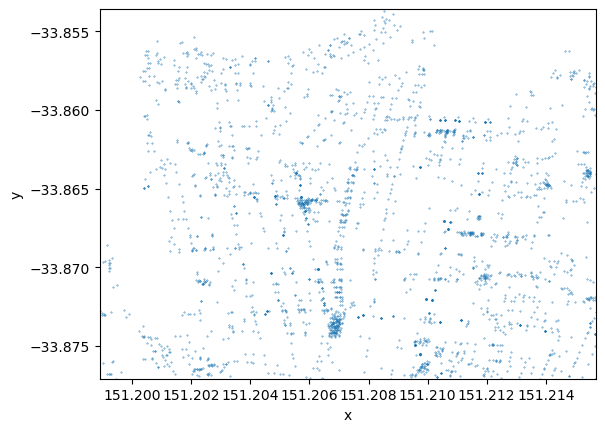

In [22]:
transit_ped_net.nodes_df.plot(kind='scatter',
                               x='x', y='y', s=0.1, xlim=(151.198899,151.215686), ylim=(-33.877090,-33.853582))

### Limit to just OSM nodes
this section as per Maury: https://github.com/ual/pandana-urbanaccess-issue/blob/main/Accessibility-solution.ipynb but slightly changed in order to use nearest_pois rather than aggregate.

In [23]:
osm_node_ids = urbanaccess_net.net_nodes.loc[urbanaccess_net.net_nodes.net_type == 'walk'].index.values
print(len(urbanaccess_net.net_nodes))
print(len(osm_node_ids))

316915
258202


In [24]:
osm_nodes = urbanaccess_net.net_nodes.reindex(osm_node_ids)  # filters for rows with index in list of values
osm_edges = urbanaccess_net.net_edges.loc[urbanaccess_net.net_edges.from_int.isin(osm_node_ids) &
                                 urbanaccess_net.net_edges.to_int.isin(osm_node_ids)]

osm_net = pdna.Network(osm_nodes["x"], 
                          osm_nodes["y"],
                          osm_edges["from_int"],
                          osm_edges["to_int"],
                          osm_edges[["weight"]], 
                          twoway=False)

In [25]:
# earlier results were with gamma 0.025, but have now changed to 0.04.
wgs_pois = pois.to_crs("EPSG:4326")
transit_max_time = 90
# need to change the distance/time decay
transit_gammas = poi_gammas.copy()
transit_gammas = transit_gammas.replace(to_replace=0.001, value=0.05)

In [72]:
results_merged = transit_ped_net.nodes_df.copy()
total_weight = sum(poi_weights)
distance = transit_max_time
return_no = 5

for category in poi_weights.index:
    results_merged = results_merged.copy()  # to remove fragmentation warning

    dim_const = poi_lambdas[category]
    dist_const = transit_gammas[category]
    num_pois = poi_nums[category]
    weight = poi_weights[category]
    cat_name = ''.join((str(category),"_",str(weight)))

    dim_opp_weight = [(1-np.exp(-dim_const*x)) - (1-np.exp(-dim_const*(x-1))) for x in range(1,num_pois+1)]
    
    if category not in poi_dictionary:
            print("Category", category, "is not in the POI dictionary")
    else:
            relevant_pois = gpd.GeoDataFrame()
            for key in poi_dictionary[category]:
                if key in wgs_pois:
                    relevant_pois = pd.concat([relevant_pois, wgs_pois.loc[(wgs_pois[key].isin(poi_dictionary[category][key]))]])
            
            if len(relevant_pois) == 0:
                print("No pois in category: "+ category)
                results_merged[str(cat_name)] = 0

            elif poi_variables[category] == 'count':
                relevant_pois['node_id'] = osm_net.get_node_ids(relevant_pois['geometry'].x, relevant_pois['geometry'].y)
                # this part is my change compared to Maury. use the node locations found earlier as the new 'locations' of the POIs
                transit_ped_net.set_pois(category=category, 
                         maxdist=transit_max_time, 
                         maxitems=num_pois, 
                         x_col=osm_net.nodes_df.loc[relevant_pois['node_id']].x, 
                         y_col=osm_net.nodes_df.loc[relevant_pois['node_id']].y)
                
                access = transit_ped_net.nearest_pois(
                    distance=transit_max_time, category=category, num_pois=num_pois)
                
                impedance = np.exp(-dist_const*access.iloc[:,0:num_pois])
                impedance[access.iloc[:,0:num_pois] == transit_max_time] = 0
                
                results_merged[cat_name] = weight*(impedance*dim_opp_weight).sum(axis=1)
                
                for i in range(return_no):
                    col_name = ''.join((str(category),str(i+1)))
                    results_merged[col_name] = access[i+1]
                    
            else:
                # makes eg. a job count column the index column, so that 'include_poi_ids' returns job counts
                relevant_pois = relevant_pois.set_index(poi_variables[category])
                
                relevant_pois['node_id'] = osm_net.get_node_ids(relevant_pois['geometry'].x, relevant_pois['geometry'].y)
                transit_ped_net.set_pois(category=category, 
                         maxdist=transit_max_time, 
                         maxitems=num_pois, 
                         x_col=osm_net.nodes_df.loc[relevant_pois['node_id']].x, 
                         y_col=osm_net.nodes_df.loc[relevant_pois['node_id']].y)
                
                access = transit_ped_net.nearest_pois(
                    distance=transit_max_time, category=category, num_pois=num_pois, include_poi_ids=True)
                
                impedance = np.exp(-dist_const*access.iloc[:,0:num_pois])
                impedance[access.iloc[:,0:num_pois] == distance] = 0
                
                attractiveness = np.nan_to_num(access.iloc[:,num_pois:2*num_pois].values, nan=0.0)
                attractiveness_sum = attractiveness.cumsum(axis=1).astype(np.int64)

                max_opps = np.max(attractiveness_sum)
                dim = np.array([(1-np.exp(-dim_const*(x+1))) - (1-np.exp(-dim_const*x)) for x in range(max_opps+1)])

                # this is no longer useful/meaningful as an output column. could output attract_sum instead
                results_merged[poi_variables[category]] = (dim[attractiveness_sum]*attractiveness*impedance).sum(axis=1)
                
                results_merged[cat_name] = weight*results_merged[poi_variables[category]]

                for i in range(return_no):
                    col_name = ''.join((str(category),str(i+1)))
                    results_merged[col_name] = access[i+1]
                    
            print("Finished category: " + category)
            print("Maximum score: " + str(max(results_merged[cat_name])) + " out of " + str(weight))
            
col_list = [''.join((str(category),"_",str(poi_weights[category])))
            for category in poi_dictionary]   
    
results_merged['THERE_Index'] = 100/total_weight*(results_merged[col_list].sum(axis=1))
results_merged['node_type'] = urbanaccess_net.net_nodes.net_type

KeyboardInterrupt: 

In [26]:
import time

In [75]:
results_merged = transit_ped_net.nodes_df.copy()
total_weight = sum(poi_weights)
distance = transit_max_time
return_no = 5
chain_frac = 0.3

t0 = time.perf_counter()

for category in ['employment']:
    results_merged = results_merged.copy()  # to remove fragmentation warning

    dim_const = poi_lambdas[category]
    dist_const = transit_gammas[category]
    num_pois = poi_nums[category]
    weight = poi_weights[category]
    cat_name = ''.join((str(category),"_",str(weight)))
    
    if category not in poi_dictionary:
            print("Category", category, "is not in the POI dictionary")
    else:
            relevant_pois = gpd.GeoDataFrame()
            for key in poi_dictionary[category]:
                if key in wgs_pois:
                    relevant_pois = pd.concat([relevant_pois, wgs_pois.loc[(wgs_pois[key].isin(poi_dictionary[category][key]))]])
                    # some duplicates arise with this method of constructing relevant_pois,
                    # because the same POI may be tagged "shopping:supermarket" and "building:supermarket"
                    # in an OSM dataset for example. We are relying on the poi index to be an unique identifier.
                    relevant_pois = relevant_pois[~relevant_pois.index.duplicated()]
            
            if len(relevant_pois) == 0:
                print("No pois in category: "+ category)
                results_merged[str(cat_name)] = 0

            else:
                if poi_variables[category] == 'count':
                    relevant_pois['attract'] = [1 for i in range(len(relevant_pois))]
                else: 
                    # makes eg. a job count column the index column, so that 'include_poi_ids' returns job counts
                    relevant_pois['attract'] = relevant_pois[poi_variables[category]]

                 # check if relevant_pois has a 'THERE' column
                if 'THERE' in relevant_pois.columns:
                    relevant_pois['chain_weight'] = (1-chain_frac) + chain_frac*relevant_pois['THERE']/100
                else:
                    relevant_pois['chain_weight'] = 1

                t1 = time.perf_counter()
                print("Time to construct relevant pois: " + str((t1-t0)/60))  

                relevant_pois['node_id'] = osm_net.get_node_ids(relevant_pois['geometry'].x, relevant_pois['geometry'].y)
                t2 = time.perf_counter()
                print("Time to get node ids: " + str((t2-t1)/60))

                relevant_pois['transit_node_id'] = transit_ped_net.get_node_ids(osm_net.nodes_df.loc[relevant_pois['node_id']].x, osm_net.nodes_df.loc[relevant_pois['node_id']].y).values
                t3 = time.perf_counter()
                print("Time to get transit node ids: " + str((t3-t2)/60))

                # construct dictionary with transit_node_id as key and node_id as value
                transit_node_dict = pd.Series(relevant_pois.index,index=relevant_pois.transit_node_id).to_dict()
                # this part is my change compared to Maury. use the node locations found earlier as the new 'locations' of the POIs
                transit_ped_net.set_pois(category=category, 
                         maxdist=transit_max_time, 
                         maxitems=num_pois, 
                         x_col=osm_net.nodes_df.loc[relevant_pois['node_id']].x, 
                         y_col=osm_net.nodes_df.loc[relevant_pois['node_id']].y)
                t4 = time.perf_counter()
                print("Time to set pois: " + str((t4-t3)/60))
                
                access = transit_ped_net.nearest_pois(
                    distance=transit_max_time, category=category, num_pois=num_pois, include_poi_ids=True)
                t5 = time.perf_counter()
                print("Time to get nearest pois: " + str((t5-t4)/60))
                
                impedance = np.exp(-dist_const*access.iloc[:,0:num_pois])
                impedance[access.iloc[:,0:num_pois] == transit_max_time] = 0

                t6 = time.perf_counter()
                print("Time to calculate impedance: " + str((t6-t5)/60))
                
                attract_dict = pd.Series(relevant_pois.attract.values,index=relevant_pois.index).to_dict()
                there_dict = pd.Series(relevant_pois.chain_weight.values,index=relevant_pois.index).to_dict()

                t7 = time.perf_counter()
                print("Time to construct dicts: " + str((t7-t6)/60))

                osm_poi_nodes = access.iloc[:,num_pois:2*num_pois].copy().convert_dtypes().applymap(lambda y: transit_node_dict.get(y,y))

                t7b = time.perf_counter()
                attract = osm_poi_nodes.applymap(lambda y: attract_dict.get(y,y))

                t7c = time.perf_counter()
                there_weight = osm_poi_nodes.applymap(lambda y: there_dict.get(y,y))

                # apparently applymap(dict.get) is faster than replace, and applymap(dict) is faster still

                t8 = time.perf_counter()
                print("Time to construct attract: " + str((t8-t7)/60))

                # nan to 0 is necessary because where eg. for some origin point, only 4 POIs of a certain category
                # are found (within distance), the returned poi_ids will be NaN for the remaining num_pois columns
                #attractiveness = np.nan_to_num(attract.values, nan=0.0)
                #there = np.nan_to_num(there_weight.values, nan=0.0)
                attractiveness = attract.fillna(0).values
                there = there_weight.fillna(0).values
                attractiveness_sum = attractiveness.cumsum(axis=1).astype(np.int64)

                dim = np.array([(1-np.exp(-dim_const*(x+1))) - (1-np.exp(-dim_const*x)) for x in attractiveness_sum])

                # this is no longer useful/meaningful as an output column. could output attract_sum instead
                results_merged[poi_variables[category]] = (dim*attractiveness*impedance*there).sum(axis=1)
                
                results_merged[cat_name] = weight*results_merged[poi_variables[category]]
                
                # this provides columns with the distance of the return_no closest destinations in the category
                for i in range(return_no):
                    col_name = ''.join((str(category),str(i+1)))
                    results_merged[col_name] = access[i+1]

                t9 = time.perf_counter()
                print("Time to calculate THERE: " + str((t9-t8)/60))
                    
            print("Finished category: " + category)
            print("Maximum score: " + str(max(results_merged[cat_name])) + " out of " + str(weight))
            
col_list = [''.join((str(category),"_",str(poi_weights[category])))
            for category in ['employment']]   
    
results_merged['THERE_Index'] = 100/total_weight*(results_merged[col_list].sum(axis=1))
results_merged['node_type'] = urbanaccess_net.net_nodes.net_type
results_merged.describe()

Time to construct relevant pois: 0.038020205000005566
Time to get node ids: 0.0021995916666734654
Time to get transit node ids: 0.0024099166666928795
Time to set pois: 0.1629051083333252


MemoryError: Unable to allocate 2.83 GiB for an array with shape (316915, 1200) and data type float64

In [47]:
osm_poi_nodes = access.iloc[:,num_pois:2*num_pois].copy().convert_dtypes().applymap(lambda y: transit_node_dict.get(y,y))

In [48]:
attract = osm_poi_nodes.applymap(lambda y: attract_dict.get(y,y))

In [69]:
attractiveness = attract.fillna(0)
there = there_weight.fillna(0)

In [64]:
attractiveness_sum = np.array(attractiveness).cumsum(axis=1).astype(np.int64)

In [65]:
attractiveness_sum

array([[     3,      5,     80, ..., 357896, 357996, 358117],
       [  1726,   1730,   1732, ..., 275426, 275751, 275761],
       [  1726,   2682,   2936, ..., 260849, 260855, 260872],
       ...,
       [     1,     31,     95, ..., 114614, 114614, 114614],
       [     1,     31,     95, ..., 110470, 110470, 110470],
       [     1,     31,     95, ..., 111873, 111873, 111873]], dtype=int64)

In [66]:
dim = np.array([(1-np.exp(-dim_const*(x+1))) - (1-np.exp(-dim_const*x)) for x in attractiveness_sum])

In [74]:
impedance

,1,2,3,4,5,6,7,8,9,10,...,1191,1192,1193,1194,1195,1196,1197,1198,1199,1200
id_int,,,,,,,,,,,,,,,,,,,,,
1,0.863553,0.798916,0.582777,0.569612,0.563775,0.560487,0.548784,0.528639,0.517550,0.507352,...,0.078748,0.078717,0.078713,0.078709,0.078705,0.078579,0.078544,0.078536,0.078485,0.078446
2,0.664347,0.583623,0.539939,0.537918,0.534914,0.525818,0.493985,0.493393,0.484785,0.471305,...,0.067952,0.067932,0.067891,0.067891,0.067861,0.067840,0.067783,0.067779,0.067725,0.067701
3,0.819591,0.663617,0.659911,0.648690,0.609419,0.608688,0.598068,0.581439,0.581264,0.574877,...,0.072814,0.072796,0.072770,0.072741,0.072730,0.072690,0.072672,0.072668,0.072643,0.072610
4,0.727748,0.627821,0.614528,0.588811,0.582573,0.581148,0.560178,0.547031,0.509004,0.508342,...,0.078340,0.078254,0.078242,0.078175,0.078070,0.078031,0.078031,0.078027,0.077988,0.077875
5,0.845523,0.713980,0.684101,0.675198,0.648496,0.635559,0.591378,0.589665,0.543922,0.534726,...,0.084260,0.084007,0.083865,0.083814,0.083685,0.083584,0.083559,0.083522,0.083442,0.083438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316911,0.573126,0.532672,0.498277,0.383468,0.329246,0.294419,0.272300,0.258451,0.243753,0.233295,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
316912,0.560543,0.544629,0.509462,0.392076,0.336637,0.301029,0.278413,0.264253,0.249225,0.238532,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
316913,0.557914,0.542076,0.507073,0.390237,0.335059,0.299617,0.277107,0.263013,0.248056,0.237414,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [70]:
(dim*attractiveness*impedance*there).sum(axis=1)

id_int
1         0.0
2         0.0
3         0.0
4         0.0
5         0.0
         ... 
316911    0.0
316912    0.0
316913    0.0
316914    0.0
316915    0.0
Length: 316915, dtype: float64

In [151]:
(t7b-t7)/60, (t7c-t7b)/60, (t8-t7c)/60

(4.550946281666499, 3.2555392033333193, 4.5714026600001185)

In [69]:
#from 1200 pois basic: max is 20.26, mean 5.4, median 4.86
# from with aggregate:
results['THERE_Index'].describe()

count    316915.000000
mean         22.177932
std          15.862228
min           0.000000
25%           7.829004
50%          20.192631
75%          35.775497
max          65.081060
Name: THERE_Index, dtype: float64

In [58]:
results = transit_ped_net.nodes_df.copy()
total_weight = sum(poi_weights)
distance = transit_max_time
return_no = 5
chain_frac = 0.3

t0 = time.perf_counter()

for category in ['employment']:
    results = results.copy()  # to remove fragmentation warning

    dim_const = poi_lambdas[category]
    dist_const = transit_gammas[category]
    num_pois = poi_nums[category]
    weight = poi_weights[category]
    cat_name = ''.join((str(category),"_",str(weight)))
    
    if category not in poi_dictionary:
            print("Category", category, "is not in the POI dictionary")
    else:
            relevant_pois = gpd.GeoDataFrame()
            for key in poi_dictionary[category]:
                if key in wgs_pois:
                    relevant_pois = pd.concat([relevant_pois, wgs_pois.loc[(wgs_pois[key].isin(poi_dictionary[category][key]))]])
                    # some duplicates arise with this method of constructing relevant_pois,
                    # because the same POI may be tagged "shopping:supermarket" and "building:supermarket"
                    # in an OSM dataset for example. We are relying on the poi index to be an unique identifier.
                    relevant_pois = relevant_pois[~relevant_pois.index.duplicated()]
            
            if len(relevant_pois) == 0:
                print("No pois in category: "+ category)
                results[str(cat_name)] = 0

            else:
                if poi_variables[category] == 'count':
                    relevant_pois['attract'] = [1 for i in range(len(relevant_pois))]
                else: 
                    # makes eg. a job count column the index column, so that 'include_poi_ids' returns job counts
                    relevant_pois['attract'] = relevant_pois[poi_variables[category]]

                 # check if relevant_pois has a 'THERE' column
                if 'THERE' in relevant_pois.columns:
                    relevant_pois['chain_weight'] = (1-chain_frac) + chain_frac*relevant_pois['THERE']/100
                else:
                    relevant_pois['chain_weight'] = 1

                t1 = time.perf_counter()  

                relevant_pois['node_id'] = osm_net.get_node_ids(relevant_pois['geometry'].x, relevant_pois['geometry'].y)
                t2 = time.perf_counter()
                relevant_pois['transit_node_id'] = transit_ped_net.get_node_ids(osm_net.nodes_df.loc[relevant_pois['node_id']].x, osm_net.nodes_df.loc[relevant_pois['node_id']].y).values
                t3 = time.perf_counter()

                t4 = time.perf_counter()

                transit_ped_net.set(node_ids = relevant_pois['transit_node_id'], variable = relevant_pois['Jobs_count'], name='jobs')
                print(type(relevant_pois['Jobs_count']), type(relevant_pois['transit_node_id']))
                
                aggreg = transit_ped_net.aggregate(distance=70, type="sum", decay = "exp", name='jobs')

                t5 = time.perf_counter()

                # this is no longer useful/meaningful as an output column. could output attract_sum instead
                results[poi_variables[category]] = aggreg/300000
                
                results[cat_name] = weight*results[poi_variables[category]]
                
                # this provides columns with the distance of the return_no closest destinations in the category
                for i in range(return_no):
                    col_name = ''.join((str(category),str(i+1)))
                    results[col_name] = access[i+1]

                t9 = time.perf_counter()
                    
            print("Finished category: " + category)
            print("Maximum score: " + str(max(results[cat_name])) + " out of " + str(weight))
            print("Time to construct relevant pois: " + str(t1-t0))
            print("Time to get node ids: " + str(t2-t1))
            print("Time to get transit node ids: " + str(t3-t2))
            print("Time to set pois: " + str(t4-t3))
            print("Time to aggregate: " + str(t5-t4))
            print("Time to calculate THERE: " + str(t9-t5))
            
col_list = [''.join((str(category),"_",str(poi_weights[category])))
            for category in ['employment']]   
    
results['THERE_Index'] = 100/total_weight*(results[col_list].sum(axis=1))
results['node_type'] = urbanaccess_net.net_nodes.net_type

<class 'pandas.core.series.Series'> <class 'pandas.core.series.Series'>
Finished category: employment
Maximum score: 65.08106035225974 out of 31.9
Time to construct relevant pois: 1.1194171999959508
Time to get node ids: 0.021167300001252443
Time to get transit node ids: 0.031950899996445514
Time to set pois: 1.400010660290718e-06
Time to aggregate: 2791.096293399998
Time to calculate THERE: 0.10454259999096394


In [61]:
len(results[results['THERE_Index']>31.9])/len(results)

0.31611630878942304

In [177]:
test_access = access.iloc[0:4,num_pois:num_pois+1205]
test_access.iloc[0,0] = None
t = test_access.convert_dtypes().applymap(lambda y: transit_node_dict.get(y)).applymap(lambda y: there_dict.get(y))
t

,poi1,poi2,poi3,poi4,poi5,poi6,poi7,poi8,poi9,poi10,...,poi1191,poi1192,poi1193,poi1194,poi1195,poi1196,poi1197,poi1198,poi1199,poi1200
id_int,,,,,,,,,,,,,,,,,,,,,
1,NaN,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,1.0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3,1.0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
4,1.0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [23]:
results.groupby('node_type',dropna=False).mean('THERE_Index')

,x,y,Jobs_count,employment_31.9,employment1,employment2,employment3,employment4,employment5,THERE_Index
node_type,,,,,,,,,,
walk,150.976992,-33.839430,0.158489,5.055799,10.558270,14.110598,15.989578,17.321655,18.302793,5.055799
NaN,151.000319,-33.831546,0.216487,6.905946,8.153502,9.950589,11.067899,11.994438,12.735494,6.905946


In [24]:
max(results.THERE_Index), np.mean(results.THERE_Index)

(20.249769742703226, 5.398564695345359)

In [65]:
# look at specific nodes, I think they're in Camden
access.loc[10688][1180:1201]

1181        66.530998
1182        66.566002
1183        66.566002
1184        66.608002
1185        66.625000
1186        66.625000
1187        66.628998
1188        66.652000
1189        66.665001
1190        66.668999
1191        66.669998
1192        66.684998
1193        66.697998
1194        66.706001
1195        66.718002
1196        66.727997
1197        66.782997
1198        66.789001
1199        66.799004
1200        66.814003
poi1    254986.000000
Name: 10688, dtype: float64

In [44]:
results.loc[10688]

x                   151.1129
y                 -34.070627
Jobs_count          0.181037
employment_31.9     5.775089
employment1            3.289
employment2             4.45
employment3            4.572
employment4             7.05
employment5            8.502
THERE_Index         5.775089
node_type                NaN
Name: 10688, dtype: object

In [60]:
access.loc[10688][2300:2400]

poi1101    259533.0
poi1102    279087.0
poi1103    220034.0
poi1104    247046.0
poi1105    224210.0
             ...   
poi1196    211124.0
poi1197    230366.0
poi1198    262599.0
poi1199    221511.0
poi1200    222352.0
Name: 10688, Length: 100, dtype: float64

In [62]:
impedance.loc[10688]

1       0.848360
2       0.800515
3       0.795647
4       0.702929
5       0.653704
          ...   
1196    0.035565
1197    0.035467
1198    0.035456
1199    0.035439
1200    0.035412
Name: 10688, Length: 1200, dtype: float64

In [59]:
access.loc[10688][(access.loc[10688]>282620)&(access.loc[10688]<282630)]

Series([], Name: 10688, dtype: float64)

In [ ]:
is 282,624 in the access results set for 10688 - no

In [31]:
gpd.GeoDataFrame(result_rounding(results), 
                                   geometry = gpd.GeoSeries.from_xy(
                                       results.x, results.y, crs="EPSG:4326")).to_file((output + "transit_test_051023_full.gpkg"))

In [67]:
first_results = results.copy()

In [42]:
transit_results = there_index(transit_ped_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=transit_max_time)

Finished category: employment
Maximum score: 23.103317631383412 out of 31.9
Finished category: education
Maximum score: 13.448012896059852 out of 14.3
Finished category: shopping
Maximum score: 21.571687530650138 out of 21.6
Finished category: errands
Maximum score: 8.85283693447956 out of 8.9
Finished category: recreation
Maximum score: 23.282617059373326 out of 23.3


In [43]:
max(transit_results.THERE_Index), np.mean(transit_results.THERE_Index)

(85.73469132971128, 53.592884836094875)

### Checking Camden employment results in detail

In [170]:
results = transit_ped_net.nodes_df.copy()
total_weight = sum(poi_weights)
distance = transit_max_time
return_no = 5

category = 'employment'

dim_const = poi_lambdas[category]
dist_const = transit_gammas[category]
num_pois = poi_nums[category]
weight = poi_weights[category]
cat_name = ''.join((str(category),"_",str(weight)))

dim_opp_weight = [(1-np.exp(-dim_const*x)) - (1-np.exp(-dim_const*(x-1))) for x in range(1,num_pois+1)]

relevant_pois = gpd.GeoDataFrame()
for key in poi_dictionary[category]:
    if key in wgs_pois:
        relevant_pois = pd.concat([relevant_pois, wgs_pois.loc[(wgs_pois[key].isin(poi_dictionary[category][key]))]])

In [172]:
relevant_pois['node_id'] = osm_net.get_node_ids(relevant_pois['geometry'].x, relevant_pois['geometry'].y)

In [204]:
relevant_pois['node_id'] = osm_net.get_node_ids(relevant_pois['geometry'].x, relevant_pois['geometry'].y)
# have to do array thing or something about duplicate indexes
relevant_pois['node_x'] = osm_net.nodes_df.loc[relevant_pois['node_id']].x.array
relevant_pois['node_y'] = osm_net.nodes_df.loc[relevant_pois['node_id']].y.array

# makes eg. a job count column the index column, so that 'include_poi_ids' returns job counts
relevant_pois = relevant_pois.set_index(poi_variables[category])

transit_ped_net.set_pois(category=category, 
         maxdist=transit_max_time, 
         maxitems=num_pois, 
         x_col=relevant_pois['node_x'], 
         y_col=relevant_pois['node_y'])

access = transit_ped_net.nearest_pois(
    distance=transit_max_time, category=category, num_pois=num_pois, include_poi_ids=True)

In [ ]:
# something has gone wrong in here and it's taking 10x longer than it should
# indexing thing is wrong now
# so the max_opps is incredibly high - sum of fids not Jobs_count

impedance = np.exp(-dist_const*access.iloc[:,0:num_pois])
impedance[access.iloc[:,0:num_pois] == distance] = 0

attractiveness = np.nan_to_num(access.iloc[:,num_pois:2*num_pois].values, nan=0.0)
attractiveness_sum = attractiveness.cumsum(axis=1).astype(np.int64)

max_opps = np.max(attractiveness_sum)
dim = np.array([(1-np.exp(-dim_const*(x+1))) - (1-np.exp(-dim_const*x)) for x in range(max_opps+1)])

# this is no longer useful/meaningful as an output column. could output attract_sum instead
results[poi_variables[category]] = (dim[attractiveness_sum]*attractiveness*impedance).sum(axis=1)

results[cat_name] = weight*results[poi_variables[category]]

for i in range(return_no):
    col_name = ''.join((str(category),str(i+1)))
    results[col_name] = access[i+1]

print("Finished category: " + category)
print("Maximum score: " + str(max(results[cat_name])) + " out of " + str(weight))
            
col_list = [''.join((str(category),"_",str(poi_weights[category])))
            for category in poi_dictionary]   

In [208]:
#results['THERE_Index'] = 100/total_weight*(results[col_list].sum(axis=1))
results['node_type'] = urbanaccess_net.net_nodes.net_type

In [149]:
pois[pois['category']=='employment']

,tourism,geometry,name,source,natural,wikidata,direction,amenity,operator,brand,...,DZNs w MB employment areas_Education,DZNs w MB employment areas_Hospital/Medical,DZNs w MB employment areas_Industrial,DZNs w MB employment areas_Other,DZNs w MB employment areas_Primary Production,DZNs w MB employment areas_Sum Empl. MB Areas,DZNs w MB employment areas_DZN_jobs,DZNs w MB employment areas_jobs_area,Jobs_count,category
1139,NaN,POINT (285241.884 6226834.071),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,,,12.721,37.3542,50.0752,887,17.71335911,131.290,employment
1156,NaN,POINT (284939.102 6227926.053),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,,,12.721,37.3542,50.0752,887,17.71335911,20.050,employment
5924,NaN,POINT (288764.127 6227332.802),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,,0.3418,9.4797,3.1956,13.0171,770,59.15296034,93.893,employment
1120,NaN,POINT (287347.101 6227716.347),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0311,0.0231,,,7.4119,7.4661,393,52.63792341,1.637,employment
6618,NaN,POINT (295026.878 6220114.869),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,,,,70.5018,46.4509,116.9527,342,2.924259124,76.284,employment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999,NaN,POINT (288647.922 6294220.837),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0842,,,92.2955,11.2869,103.6666,282,2.720258984,23.034,employment
2266,NaN,POINT (286755.513 6294029.683),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0842,,,92.2955,11.2869,103.6666,282,2.720258984,8.275,employment
2115,NaN,POINT (285094.098 6289910.397),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0842,,,92.2955,11.2869,103.6666,282,2.720258984,7.411,employment
2280,NaN,POINT (286139.713 6290199.506),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0842,,,92.2955,11.2869,103.6666,282,2.720258984,0.166,employment


In [205]:
access.loc[199165][1190:1230]

1191       30.466000
1192       30.478001
1193       30.509001
1194       30.514000
1195       30.525999
1196       30.535000
1197       30.540001
1198       30.548000
1199       30.563000
1200       30.576000
poi1      254.538000
poi2      112.151000
poi3     2111.752000
poi4     1021.812000
poi5      708.592000
poi6       93.337000
poi7       35.683000
poi8      617.127000
poi9      380.100000
poi10    2348.680000
poi11    1155.096000
poi12     168.766000
poi13     719.643000
poi14     159.420000
poi15    2135.600000
poi16     448.472000
poi17     149.207000
poi18     197.647000
poi19     190.588000
poi20     236.582000
poi21     670.201000
poi22     476.857000
poi23    1517.161000
poi24     459.149000
poi25    2519.327000
poi26     241.957000
poi27    1053.815000
poi28     138.099000
poi29     162.000000
poi30     231.543000
Name: 199165, dtype: float64

In [158]:
access.loc[199165][1190:1230]

1191         30.466000
1192         30.478001
1193         30.509001
1194         30.514000
1195         30.525999
1196         30.535000
1197         30.540001
1198         30.548000
1199         30.563000
1200         30.576000
poi1     199165.000000
poi2     199165.000000
poi3     254587.000000
poi4     199200.000000
poi5     305216.000000
poi6     277084.000000
poi7     198431.000000
poi8     256789.000000
poi9     303025.000000
poi10    277083.000000
poi11    302923.000000
poi12    261168.000000
poi13    253389.000000
poi14    281368.000000
poi15    275808.000000
poi16    265297.000000
poi17    304010.000000
poi18    304010.000000
poi19    197836.000000
poi20    236678.000000
poi21    263222.000000
poi22    281388.000000
poi23    279474.000000
poi24    286832.000000
poi25    272095.000000
poi26    199171.000000
poi27    283048.000000
poi28    306267.000000
poi29    300353.000000
poi30    223662.000000
Name: 199165, dtype: float64

In [135]:
impedance.loc[199165]

1       1.000000
2       1.000000
3       0.908918
4       0.878315
5       0.827869
          ...   
1196    0.217241
1197    0.217186
1198    0.217099
1199    0.216937
1200    0.216796
Name: 199165, Length: 1200, dtype: float64

In [209]:
results['employment_31.9'][199165]

18.31676969729903

In [210]:
results['employment_31.9'][19374]

4.305638805318488

In [213]:
results

,x,y,Jobs_count,employment_31.9,employment1,employment2,employment3,employment4,employment5,node_type
id_int,,,,,,,,,,
1,150.892743,-33.972461,0.257346,8.209324,2.207,2.934,4.490,9.961000,10.799000,NaN
2,150.911767,-33.950285,0.255426,8.148089,6.561,8.179,10.043,10.117000,10.770000,NaN
3,150.927287,-33.924739,0.302505,9.649917,2.361,3.979,5.917,6.735000,7.247000,NaN
4,150.935067,-33.913173,0.278849,8.895292,6.356,6.537,7.607,7.692000,7.760000,NaN
5,150.938786,-33.894896,0.286750,9.147316,3.356,3.537,4.607,4.760000,5.226000,NaN
...,...,...,...,...,...,...,...,...,...,...
316911,150.454096,-33.723596,0.038286,1.221321,11.133,12.597,13.932,17.891001,18.476999,walk
316912,150.454236,-33.723758,0.039127,1.248162,11.577,12.153,13.488,17.447001,18.033001,walk
316913,150.454271,-33.723789,0.038942,1.242252,11.671,12.247,13.582,17.541000,18.127001,walk


In [212]:
combined_results = first_results.copy()

In [219]:
combined_results['THERE_Index'] = combined_results['THERE_Index'] - combined_results['employment_31.9']

In [220]:
combined_results['employment_31.9'] = results['employment_31.9']

In [221]:
combined_results['THERE_Index'] = combined_results['THERE_Index'] + combined_results['employment_31.9']

In [222]:
combined_results['Jobs_count'] = results['Jobs_count']
combined_results['employment1'] = results['employment1']
combined_results['employment2'] = results['employment2']
combined_results['employment3'] = results['employment3']
combined_results['employment4'] = results['employment4']
combined_results['employment5'] = results['employment5']

In [223]:
result_gpd = gpd.GeoDataFrame(result_rounding(combined_results), 
                                   geometry = gpd.GeoSeries.from_xy(combined_results.x, combined_results.y, crs='EPSG:4326'))
result_gpd.to_file((output + "transit_full_070123.gpkg"))

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\io\file.py:389: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(gdal_version) >= LooseVersion("3.0.0") and crs:


In [224]:
result_rounding(combined_results.filter(regex='x|y$|_')).to_csv(output + "Sydney_transit_070123.csv")

## Export results

Reduce the number of decimal places before export, distances do not need to be below 1m.

In [28]:
def result_rounding(results):
    # reduces results size for export
    # score columns such as THERE_Index, employment_subtotal etc -> 3 decimal places
    # distance columns such as employment1 -> 0 decimal places (nearest metre)
    # avoid doing anything to connect_id, x or y
    rounding_dict = {**{k:3 for k in results.columns if "Index" in k or "." in k
                        and 'connect_id' not in k},
                     **{k:0 for k in results.columns if "Index" not in k and "." not in k
                        and k != 'x'
                        and k != 'y'}}
    return results.round(rounding_dict)

In [30]:
output = 'C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\HPM take 2\\'

In [111]:
c_imp_gpd = gpd.GeoDataFrame(result_rounding(results_cycle_impedance), 
                                   geometry = gpd.GeoSeries.from_xy(results_cycle_impedance.x, results_cycle_impedance.y, crs=proj_crs))

In [117]:
c_imp_gpd.to_file((output + "Sydney_cycle_impedance_291122.gpkg"))

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\io\file.py:389: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(gdal_version) >= LooseVersion("3.0.0") and crs:


In [48]:
drive_gpd = gpd.GeoDataFrame(result_rounding(results_drive), 
                                   geometry = gpd.GeoSeries.from_xy(results_drive.x, results_drive.y, crs=proj_crs))

In [49]:
drive_gpd.to_file((output + "Sydney_drive_151222.gpkg"))

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\io\file.py:389: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(gdal_version) >= LooseVersion("3.0.0") and crs:


In [50]:
transit_gpd = gpd.GeoDataFrame(result_rounding(transit_results), 
                                   geometry = gpd.GeoSeries.from_xy(transit_results.x, transit_results.y, crs="EPSG:4326"))

In [51]:
transit_gpd.to_file((output + "Sydney_transit_151222.gpkg"))

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\io\file.py:389: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(gdal_version) >= LooseVersion("3.0.0") and crs:


In [60]:
result_rounding(results_walk.filter(regex='x|y$|_')).to_csv(output + "Sydney_walk_241122.csv")

In [61]:
result_rounding(results_cycle.filter(regex='x|y$|_')).to_csv(output + "Sydney_cycle_naive_241122.csv")

In [61]:
result_rounding(results_cycle_selective.filter(regex='x|y$|_')).to_csv(output + "Sydney_cycle_select_241122.csv")

In [116]:
result_rounding(results_cycle_impedance.filter(regex='x|y$|_')).to_csv(output + "Sydney_cycle_impedance_291122.csv")

In [52]:
result_rounding(results_drive.filter(regex='x|y$|_')).to_csv(output + "Sydney_drive_151222.csv")

In [53]:
result_rounding(transit_results.filter(regex='x|y$|_')).to_csv(output + "Sydney_transit_151222.csv")

### Combine results
For this analysis, we don't actually need to combine results in one dataframe. Each set of results is at different origins, owing to the different nodes in each network. Best to export as 4 separate results sets.

## Comparative visualisations

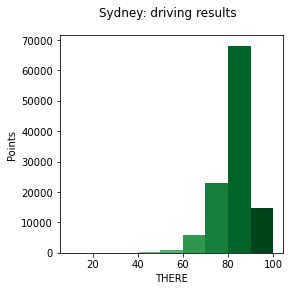

In [54]:
cm = plt.cm.Greens
bins=[10,20,30,40,50,60,70,80,90,100]
fig, ax1 = plt.subplots(nrows=1, ncols=1, sharey=True, figsize=(12, 4))
fig.set_figwidth(4)
ax1.set_xlabel('THERE')
ax1.set_ylabel('Points')
fig.suptitle('Sydney: driving results')

n, bins, patches = plt.hist(results_drive['THERE_Index'], label='Drive',bins=bins)
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(i/10 + 0.2)) # notice the i/25
    
plt.show()

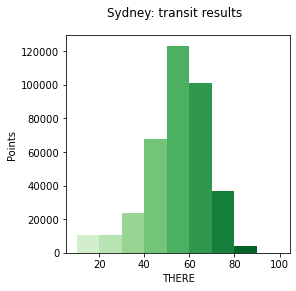

In [55]:
cm = plt.cm.Greens
bins=[10,20,30,40,50,60,70,80,90,100]
fig, ax1 = plt.subplots(nrows=1, ncols=1, sharey=True, figsize=(12, 4))
fig.set_figwidth(4)
ax1.set_xlabel('THERE')
ax1.set_ylabel('Points')
fig.suptitle('Sydney: transit results')

n, bins, patches = plt.hist(transit_results['THERE_Index'], label='transit',bins=bins)
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(i/10 + 0.2)) # notice the i/25
    
plt.show()

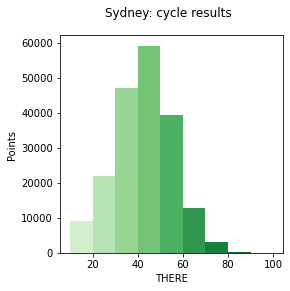

In [113]:
cm = plt.cm.Greens
bins=[10,20,30,40,50,60,70,80,90,100]
fig, ax1 = plt.subplots(nrows=1, ncols=1, sharey=True, figsize=(12, 4))
fig.set_figwidth(4)
ax1.set_xlabel('THERE')
ax1.set_ylabel('Points')
fig.suptitle('Sydney: impedance cycle results')

n, bins, patches = plt.hist(results_cycle_impedance['THERE_Index'], label='Cycle - impedance',bins=bins)
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(i/10 + 0.2)) # notice the i/25
    
plt.show()

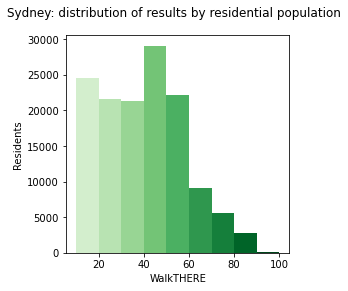

In [321]:
cm = plt.cm.Greens
bins=[10,20,30,40,50,60,70,80,90,100]
fig, ax1 = plt.subplots(nrows=1, ncols=1, sharey=True, figsize=(12, 4))
fig.set_figwidth(4)
ax1.set_xlabel('THERE')
ax1.set_ylabel('Points')
fig.suptitle('Sydney: cycle results')

n, bins, patches = plt.hist(results_cycle_selective['THERE_Index'], label='Cycle - selective',bins=bins)
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(i/10 + 0.2)) # notice the i/25
    
plt.show()

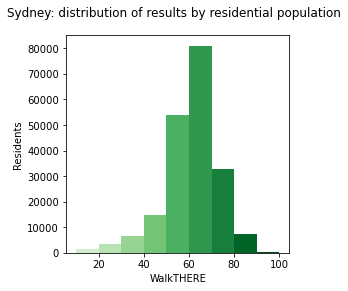

In [322]:
cm = plt.cm.Greens
bins=[10,20,30,40,50,60,70,80,90,100]
fig, ax1 = plt.subplots(nrows=1, ncols=1, sharey=True, figsize=(12, 4))
fig.set_figwidth(4)
ax1.set_xlabel('THERE')
ax1.set_ylabel('Points')
fig.suptitle('Sydney: cycle results')

n, bins, patches = plt.hist(results_cycle['THERE_Index'], label='Cycle - broad',bins=bins)
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(i/10 + 0.2)) # notice the i/25
    
plt.show()

In [34]:
small_w_results.to_file((folder + "Sydney Data\\Sydney full results walk 181022.gpkg"))

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\io\file.py:389: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(gdal_version) >= LooseVersion("3.0.0") and crs:


### Visualise results

In [56]:
import matplotlib_scalebar 
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import Point

In [57]:
envelope = small_w_results.to_crs("EPSG:4326").unary_union.envelope
envelope = gpd.GeoDataFrame({'geometry': envelope, 'convex_hull':[1]},crs=proj_crs)
graph_envelope = gpd.GeoDataFrame({'geometry': small_w_results.to_crs("EPSG:4326").unary_union.envelope, 'convex_hull':[1]},crs="EPSG:4326")

NameError: name 'small_w_results' is not defined

In [37]:
Australia = gpd.read_file("C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Data\\ABS Data\\2016_GCCSA_aust_shape\\GCCSA_2016_AUST.shp").to_crs(proj_crs)
Sydney = Australia.clip(envelope)
graph_Sydney = Australia.to_crs("EPSG:4326")
graph_Sydney = graph_Sydney.clip(graph_envelope)

In [40]:
# uses every third row to speed up plotting. The maps are still considerably over-plotted, for large cities at this figure size.

graph_data = small_w_results.iloc[::3, :].to_crs("EPSG:4326")

points = gpd.GeoSeries([Point(150, -33.8), Point(151, -33.8)], crs=4326)  # Geographic WGS 84 - degrees
points = points.to_crs(32619) # Projected WGS 84 - meters
distance_meters = points[0].distance(points[1])

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopanda

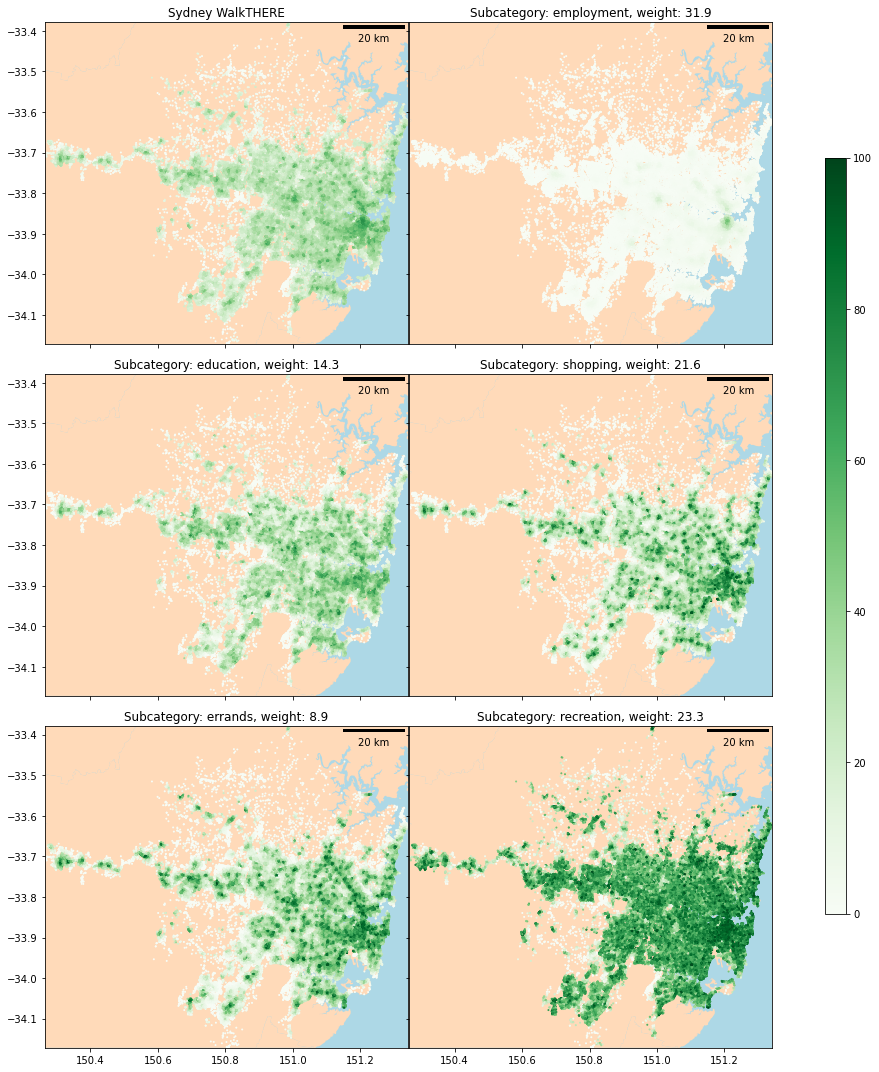

In [42]:
fig, axs = plt.subplots(3,2, sharex=True, sharey=True, 
                       subplot_kw=dict(facecolor="lightblue",xmargin=0,ymargin=0), 
                       figsize=(12,15))

#for ticker, ax in zip(tickers, axs.ravel()):
for ax in axs.ravel():
    graph_Sydney.plot(ax = ax, zorder=1, color='peachpuff')
    ax.add_artist(ScaleBar(distance_meters, frameon=False))

# put overall index in the first subplot
graph_data.plot(ax = axs[0,0], zorder=2, column= "THERE_Index", 
                     cmap='Greens', markersize=1, vmin=0, vmax=100)
axs[0,0].set_title("Sydney WalkTHERE")

for cat in zip(range(0,len(poi_weights)),poi_weights.items()):
    i = cat[0] + 1 # to skip the first subplot
    ax = axs[i//2,i%2]
    graph_data.plot(ax = ax, zorder=2,
                    column = (cat[1][0] + "_" + str(cat[1][1])),
                    cmap='Greens', markersize=1, vmin=0, vmax = cat[1][1])
    ax.set_title("Subcategory: "+cat[1][0]+", weight: "+str(cat[1][1]))
    
plt.tight_layout()

# Create colorbar scale
sm = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=0, vmax=100))
 # empty array for the data range
sm._A = []
# add the colorbar to the figure
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.95,0.15,0.025,0.7])
fig.colorbar(sm, cax=cbar_ax)

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


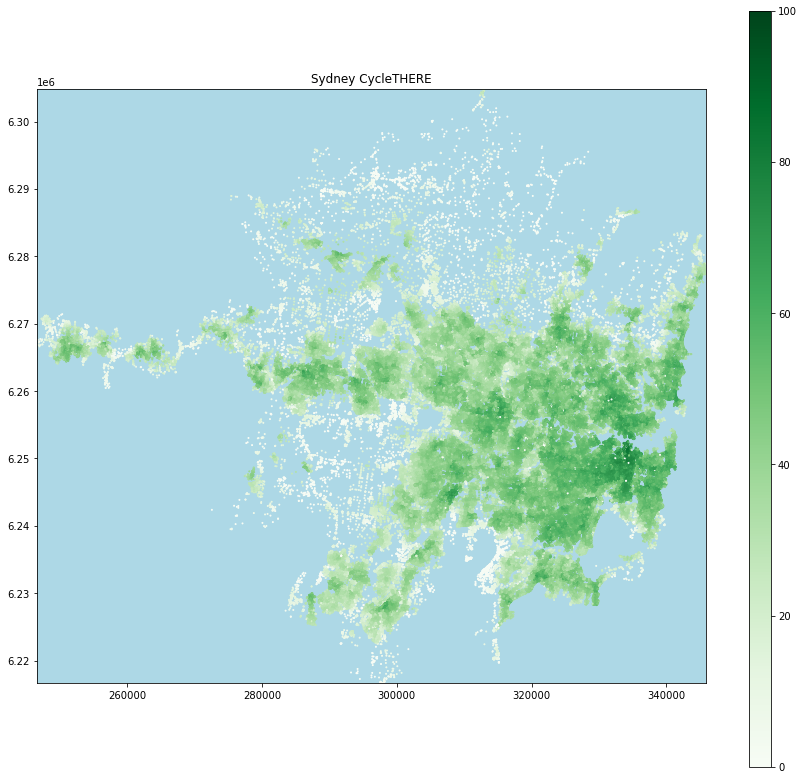

In [112]:
fig, axs = plt.subplots(1,1,
                       subplot_kw=dict(facecolor="lightblue",xmargin=0,ymargin=0), 
                       figsize=(12,15))


# put overall index in the first subplot
c_imp_gpd.plot(ax = axs, zorder=2, column= "THERE_Index", 
                     cmap='Greens', markersize=1, vmin=0, vmax=100)
axs.set_title("Sydney CycleTHERE")

# Create colorbar scale
sm = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=0, vmax=100))
 # empty array for the data range
sm._A = []
# add the colorbar to the figure
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.95,0.15,0.025,0.7])
fig.colorbar(sm, cax=cbar_ax)

C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users\z3258367\Anaconda3\envs\ox\lib\site-packages\setuptools\_distutils\version.py:351: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


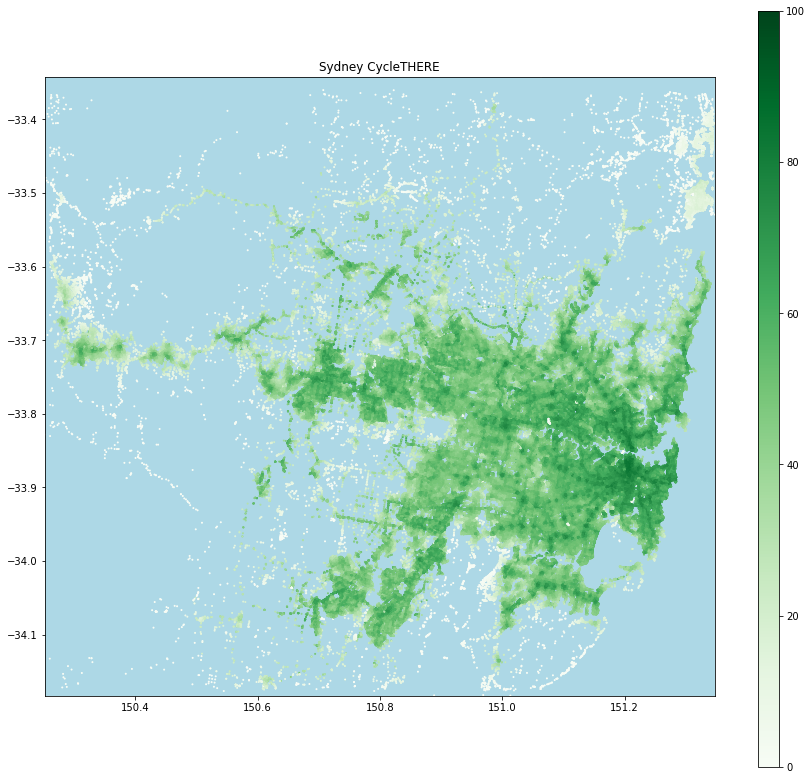

In [58]:
fig, axs = plt.subplots(1,1,
                       subplot_kw=dict(facecolor="lightblue",xmargin=0,ymargin=0), 
                       figsize=(12,15))


# put overall index in the first subplot
transit_gpd.plot(ax = axs, zorder=2, column= "THERE_Index", 
                     cmap='Greens', markersize=1, vmin=0, vmax=100)
axs.set_title("Sydney CycleTHERE")

# Create colorbar scale
sm = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=0, vmax=100))
 # empty array for the data range
sm._A = []
# add the colorbar to the figure
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.95,0.15,0.025,0.7])
fig.colorbar(sm, cax=cbar_ax)